# Bootstrap Resampling

Bootstrapping is a resampling technique that estimates the sampling distribution of almost any statistic **without parametric assumptions**. It works by repeatedly sampling *with replacement* from the observed data and computing the statistic on each resample.

**Why it matters:** It gives confidence intervals for statistics where no closed-form formula exists (median, correlation, ratio of means, etc.).

## Core Idea

Given data $X = \{x_1, \ldots, x_n\}$:
1. Draw $B$ bootstrap samples $X^*_b$ of size $n$ **with replacement**
2. Compute the statistic $\hat{\theta}^*_b$ on each sample
3. The distribution of $\{\hat{\theta}^*_1, \ldots, \hat{\theta}^*_B\}$ approximates the sampling distribution of $\hat{\theta}$
4. The **95% percentile CI** is $[\hat{\theta}^*_{2.5\%},\ \hat{\theta}^*_{97.5\%}]$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=42)

# Observed data: reaction times (ms), right-skewed
data = rng.exponential(scale=250, size=40) + 150
print(f'Sample size  : {len(data)}')
print(f'Sample mean  : {data.mean():.2f} ms')
print(f'Sample median: {np.median(data):.2f} ms')
print(f'Std deviation: {data.std(ddof=1):.2f} ms')


Sample size  : 40
Sample mean  : 359.60 ms
Sample median: 287.83 ms
Std deviation: 190.50 ms


## Bootstrap CI for the Mean

Bootstrap 95% CI for mean : (303.59, 420.12) ms
Parametric t  95% CI      : (298.67, 420.53) ms



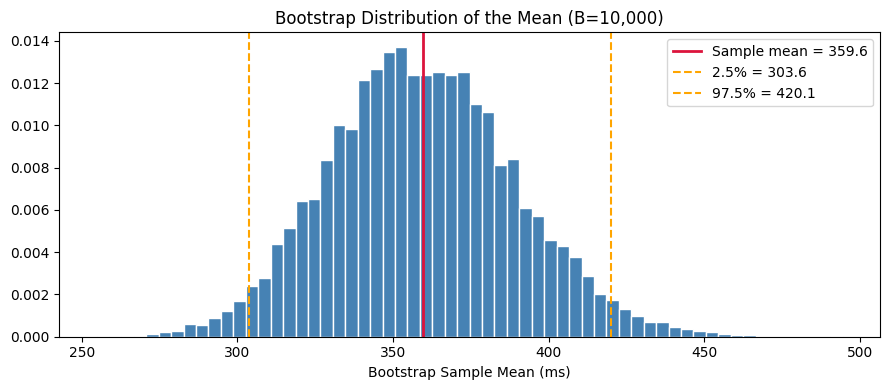

In [2]:
B = 10_000   # number of bootstrap resamples

boot_means = np.array([
    rng.choice(data, size=len(data), replace=True).mean()
    for _ in range(B)
])

ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])

# Compare with parametric t-interval
t_lo, t_hi = stats.t.interval(0.95, df=len(data)-1,
                                loc=data.mean(),
                                scale=stats.sem(data))

print(f'Bootstrap 95% CI for mean : ({ci_lo:.2f}, {ci_hi:.2f}) ms')
print(f'Parametric t  95% CI      : ({t_lo:.2f}, {t_hi:.2f}) ms')
print()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(boot_means, bins=60, color='steelblue', edgecolor='white', density=True)
ax.axvline(data.mean(), color='crimson', lw=2, label=f'Sample mean = {data.mean():.1f}')
ax.axvline(ci_lo, color='orange', lw=1.5, ls='--', label=f'2.5% = {ci_lo:.1f}')
ax.axvline(ci_hi, color='orange', lw=1.5, ls='--', label=f'97.5% = {ci_hi:.1f}')
ax.set_xlabel('Bootstrap Sample Mean (ms)')
ax.set_title('Bootstrap Distribution of the Mean (B=10,000)')
ax.legend()
plt.tight_layout()
plt.show()


## Bootstrap CI for the Median

No closed-form formula exists for the CI of the median. Bootstrap handles this effortlessly.

In [3]:
boot_medians = np.array([
    np.median(rng.choice(data, size=len(data), replace=True))
    for _ in range(B)
])

med_lo, med_hi = np.percentile(boot_medians, [2.5, 97.5])
print(f'Sample median               : {np.median(data):.2f} ms')
print(f'Bootstrap 95% CI for median : ({med_lo:.2f}, {med_hi:.2f}) ms')
print()
print('The bootstrap CI for the median has no parametric equivalent for small n.')
print('This is one of bootstrap\'s greatest strengths.')


Sample median               : 287.83 ms
Bootstrap 95% CI for median : (241.34, 393.47) ms

The bootstrap CI for the median has no parametric equivalent for small n.
This is one of bootstrap's greatest strengths.


## Bootstrap Hypothesis Test

To test $H_0: \mu = \mu_0$, shift the bootstrap distribution to be centred at $\mu_0$, then measure how often the resampled statistic exceeds the observed one.

In [4]:
# H0: population mean reaction time = 350 ms
mu_0 = 350
observed_mean = data.mean()

# Shift data so the sample mean equals mu_0
shifted = data - observed_mean + mu_0

boot_shifted = np.array([
    rng.choice(shifted, size=len(shifted), replace=True).mean()
    for _ in range(B)
])

# Two-tailed p-value
p_boot = np.mean(np.abs(boot_shifted - mu_0) >= np.abs(observed_mean - mu_0))

print(f'H0: mu = {mu_0} ms')
print(f'Observed mean    : {observed_mean:.2f} ms')
print(f'Bootstrap p-value: {p_boot:.4f}')
if p_boot < 0.05:
    print('Reject H0: mean significantly different from 350 ms.')
else:
    print('Fail to reject H0.')

# Compare with parametric one-sample t-test
_, p_t = stats.ttest_1samp(data, popmean=mu_0)
print(f'Parametric t-test p-value: {p_t:.4f}')


H0: mu = 350 ms
Observed mean    : 359.60 ms
Bootstrap p-value: 0.7438
Fail to reject H0.
Parametric t-test p-value: 0.7517


---
## ML/AI Connection

- **Bagging (Bootstrap Aggregating):** Random Forests and gradient boosting train each tree on a bootstrap sample of the training data — the core of ensemble methods.
- **Bootstrap CI for model performance:** instead of asymptotic CIs, resample the test set with replacement to get CIs for accuracy, AUC, or F1 score.
- **The .632+ bootstrap estimator** is a bias-corrected estimate of generalisation error, combining in-bag and out-of-bag error rates.
